In [1]:
# from xopr_gline import xopr_utils
import numpy as np
import xarray as xr
import hvplot.xarray
import matplotlib.pyplot as plt
import scipy.constants
from scipy import signal
import pandas as pd
import geopandas as gpd
import xopr.opr_access
import xopr.geometry
import dask
from dask.distributed import LocalCluster
import cartopy.crs as ccrs
import geoviews.feature as gf
import time
import requests
from scipy.optimize import curve_fit

from xopr_gline.xopr_utils import extract_layer_peak_power, surface_bed_reflection_power, get_basal_layer_wgs84
from xopr_gline.empirical import erf_topography_model, get_derivatives

%matplotlib widget 

In [2]:
opr = xopr.opr_access.OPRConnection(cache_dir="/tmp")

In [3]:
# Select a segment
selected_collection = "2008_Greenland_TO"
selected_segment = "20080730_01"
print(f"Selected segment: {selected_segment}")

# Query frames
stac_items = opr.query_frames(
    collections=[selected_collection], segment_paths=[selected_segment]
)
print(f"Found {len(stac_items)} frames")
stac_items = stac_items.iloc[:5]
stac_items

Selected segment: 20080730_01
Found 16 frames


,collection,geometry,properties,assets,bbox,id,links,stac_extensions,stac_version,type
stac_item_id,,,,,,,,,,
Data_20080730_01_001,2008_Greenland_TO,"LINESTRING (-38.01843 66.21311, -38.97617 66.2...",{'datetime': '2008-07-30T11:12:57.660085+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-38.976167807520895, 66.2131086513131, -38.01...",Data_20080730_01_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20080730_01_002,2008_Greenland_TO,"LINESTRING (-38.97737 66.23129, -39.70354 66.2...",{'datetime': '2008-07-30T11:21:50.264716+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-39.75532634509902, 66.23128865287966, -38.97...",Data_20080730_01_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20080730_01_003,2008_Greenland_TO,"LINESTRING (-39.757 66.24291, -39.78798 66.246...",{'datetime': '2008-07-30T11:28:06.219893+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-39.89912295367438, 66.24291173726644, -39.74...",Data_20080730_01_003,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20080730_01_004,2008_Greenland_TO,"LINESTRING (-39.74371 66.37283, -39.69568 66.3...",{'datetime': '2008-07-30T11:33:56.323620+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-39.74371217602369, 66.35413498203181, -39.04...",Data_20080730_01_004,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20080730_01_005,2008_Greenland_TO,"LINESTRING (-39.04257 66.35458, -38.99576 66.3...",{'datetime': '2008-07-30T11:42:11.595412+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-39.04256905972077, 66.34038437446095, -37.98...",Data_20080730_01_005,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature


In [4]:
# Load the radar data
frames = opr.load_frames(stac_items)
print(f"Loaded {len(frames)} frames")

Loaded 5 frames


In [5]:
# Merge frames into a single flight line
flight_line = xopr.merge_frames(frames)
flight_line

/home/m484s199/xopr-gline/.venv/lib/python3.11/site-packages/xopr/opr_tools.py:57: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  merged_segment = xr.concat(segment_frames, dim='slow_time', combine_attrs=merge_dicts_no_conflicts).sortby('slow_time')


<xarray.Dataset> Size: 145MB
Dimensions:    (slow_time: 6007, twtt: 2001)
Coordinates:
  * slow_time  (slow_time) datetime64[ns] 48kB 2008-07-30T11:07:46.134547710 ...
  * twtt       (twtt) float64 16kB -1.222e-07 -8.883e-08 ... 6.653e-05 6.656e-05
Data variables:
    Time       (slow_time, twtt) float64 96MB -1.222e-07 ... 6.656e-05
    GPS_time   (slow_time) float64 48kB 1.217e+09 1.217e+09 ... 1.217e+09
    Latitude   (slow_time) float64 48kB 66.21 66.21 66.21 ... 66.34 66.34 66.34
    Longitude  (slow_time) float64 48kB -38.02 -38.02 -38.02 ... -37.99 -37.98
    Elevation  (slow_time) float64 48kB 1.05e+03 1.049e+03 ... 603.4 605.6
    Roll       (slow_time) float64 48kB -0.003719 -0.001688 ... -0.003478
    Pitch      (slow_time) float64 48kB -0.026 -0.02716 ... 0.1334 0.1312
    Heading    (slow_time) float64 48kB -1.48 -1.476 -1.475 ... 1.377 1.372
    Surface    (slow_time) float64 48kB 3.579e-06 3.579e-06 ... 3.567e-06
    Data       (twtt, slow_time) float32 48MB 3.129e-08 3.091e-08 ... 5.939e-27
Attributes: (12/17)
    mimetype:       application/x-matlab-data
    param_csarp:    {'records': {'file': {'adcs': array([1, 2, 3, 4, 5, 6], d...
    segment:        1
    param_records:  {'records': {'file': {'adcs': array([1, 2, 3, 4, 5, 6], d...
    institution:    Open Polar Radar (OPR)
    source:         Airborne/ground-based radar sounder
    ...             ...
    date_str:       20080730
    references:     https://gitlab.com/englacial/xopr
    Conventions:    CF-1.8
    collection:     2008_Greenland_TO
    source_url:     {'https://data.cresis.ku.edu/data/rds/2008_Greenland_TO/C...
    granule:        {'20080730_01_004', '20080730_01_002', '20080730_01_003',...

In [6]:
# Load layers for the merged flight line
layers = opr.get_layers(flight_line)
print(f"Available layers: {list(layers.keys())}")

Available layers: ['standard:surface', 'standard:bottom']


In [7]:
for layer_idx in layers:
    layers[layer_idx] = xopr.radar_util.add_along_track(layers[layer_idx])
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='wgs84')
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='range')

flight_line = xopr.radar_util.add_along_track(flight_line)
flight_line = xopr.radar_util.interpolate_to_vertical_grid(flight_line, vertical_coordinate='wgs84')

In [ ]:
# visualize radargram

clb_min_pct, clb_max_pct  = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(flight_line.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1)#, vmin=-310, vmax=-240) #-310 -240

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)

# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
# ax1.set_xlim(0.3e6, 0.5e6)

In [8]:
flight_line = flight_line.assign_coords({"Latitude": flight_line["Latitude"]})
flight_line = flight_line.assign_coords({"Longitude": flight_line["Longitude"]})
flight_line['along_track'].data[-1]

np.float64(182446.84382344104)

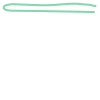

In [9]:
from shapely.geometry import Point, LineString

flight_line_proj = xopr.geometry.project_dataset(flight_line, "EPSG:3413")
xy_points = gpd.points_from_xy(flight_line_proj['x'], flight_line_proj['y'])
lon_lat_points = gpd.points_from_xy(flight_line['Longitude'], flight_line['Latitude'])

flight_line_3413 = LineString(xy_points)
flight_line_4326 = LineString(lon_lat_points)
flight_line_4326

In [10]:
import dask
from dask.distributed import LocalCluster

client = LocalCluster().get_client()

/home/m484s199/xopr-gline/.venv/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43893 instead
  warnings.warn(


In [11]:
stac_list = [row for _, row in stac_items.iterrows()]
futures = client.map(surface_bed_reflection_power, stac_list, opr=opr)

# Process results as they complete, capturing exceptions
results = []
for future in dask.distributed.as_completed(futures):
    try:
        result = future.result()
        results.append(result)
    except Exception as e:
        print(traceback.format_exc())

/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:73: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([
/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:81: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([reflectivity_dataset, flight_line_metadata])
/home/m484s199/xop

In [12]:
results[1]

<xarray.Dataset> Size: 11kB
Dimensions:           (slow_time: 123)
Coordinates:
  * slow_time         (slow_time) datetime64[ns] 984B 2008-07-30T11:07:45 ......
Data variables:
    surface_twtt      (slow_time) float64 984B nan 3.579e-06 ... 2.812e-06
    bed_twtt          (slow_time) float64 984B nan 4.112e-06 ... nan nan
    surface_power_dB  (slow_time) float32 492B nan -44.53 ... -33.52 -33.28
    bed_power_dB      (slow_time) float32 492B nan -49.51 -41.78 ... nan nan nan
    GPS_time          (slow_time) float64 984B 1.217e+09 1.217e+09 ... 1.217e+09
    Latitude          (slow_time) float64 984B 66.21 66.21 66.21 ... 66.23 66.23
    Longitude         (slow_time) float64 984B -38.02 -38.03 ... -38.97 -38.97
    Elevation         (slow_time) float64 984B 1.045e+03 1.029e+03 ... 1.927e+03
    Roll              (slow_time) float64 984B -0.002426 -0.01097 ... -0.01969
    Pitch             (slow_time) float64 984B -0.03216 -0.03768 ... 0.03404
    Heading           (slow_time) float64 984B -1.478 -1.521 ... -1.523 -1.524
Attributes:
    segment:  1

In [13]:
reflectivity_concat = xr.concat(results, dim="slow_time").sortby("slow_time")
reflectivity_concat

<xarray.Dataset> Size: 42kB
Dimensions:           (slow_time: 477)
Coordinates:
  * slow_time         (slow_time) datetime64[ns] 4kB 2008-07-30T11:07:45 ... ...
Data variables:
    surface_twtt      (slow_time) float64 4kB nan 3.579e-06 ... 3.712e-06
    bed_twtt          (slow_time) float64 4kB nan 4.112e-06 ... 3.712e-06
    surface_power_dB  (slow_time) float32 2kB nan -44.53 ... -43.22 -39.91
    bed_power_dB      (slow_time) float32 2kB nan -49.51 ... -43.22 -39.91
    GPS_time          (slow_time) float64 4kB 1.217e+09 1.217e+09 ... 1.217e+09
    Latitude          (slow_time) float64 4kB 66.21 66.21 66.21 ... 66.34 66.34
    Longitude         (slow_time) float64 4kB -38.02 -38.03 ... -38.0 -37.99
    Elevation         (slow_time) float64 4kB 1.045e+03 1.029e+03 ... 593.6
    Roll              (slow_time) float64 4kB -0.002426 -0.01097 ... -0.01423
    Pitch             (slow_time) float64 4kB -0.03216 -0.03768 ... 0.144 0.1381
    Heading           (slow_time) float64 4kB -1.478 -1.521 ... 1.489 1.402
Attributes:
    segment:  1

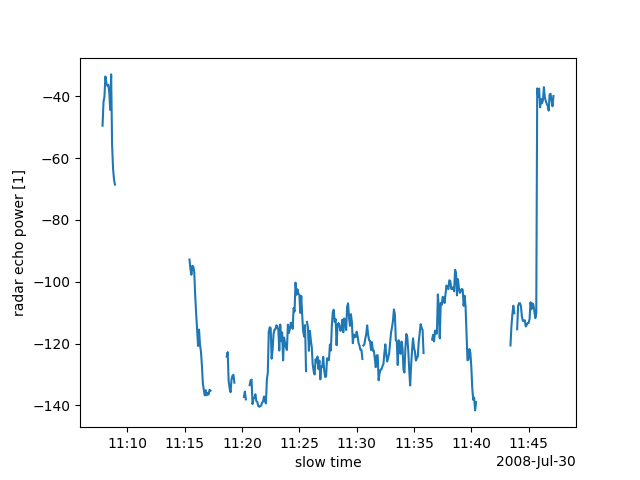

In [14]:
reflectivity_concat['bed_power_dB'].plot()

In [15]:
reflectivity_concat = xopr.radar_util.add_along_track(reflectivity_concat)

In [16]:
# Get thickness
H = layers['standard:surface']['wgs84'] - layers['standard:bottom']['wgs84']
# Get a thickness mask so max gradient is over glacier and not melange or other noise
H_mask = H > 50
H.plot()

In [17]:
H_filt = H[H_mask]
thick_slow_time_min = H_filt.slow_time.min()
thick_slow_time_max = H_filt.slow_time.max()

In [18]:
bed_power_grad = np.gradient(reflectivity_concat['bed_power_dB']) # the Xia paper takes the second derivative but that looks worse
reflectivity_concat['bed_power_grad'] = (('slow_time'), bed_power_grad)
bed_power_grad_filter = reflectivity_concat['bed_power_grad'].sel(slow_time=slice(thick_slow_time_min, thick_slow_time_max) )

# get the index of the peak bed power and grab the bed elevation index too
grad_max_idx = bed_power_grad_filter.argmax(dim="slow_time").data
grad_max = bed_power_grad_filter.max()

grad_slowtime = bed_power_grad_filter['slow_time'][grad_max_idx]
bed_point = layers['standard:bottom']['wgs84'].sel(slow_time=grad_slowtime.data, method='nearest')
bed_point

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-580.17106259)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T11:45:39.852538109
    along_track  float64 8B 1.75e+05
Attributes:
    units:        meters
    description:  WGS84 elevation of layer

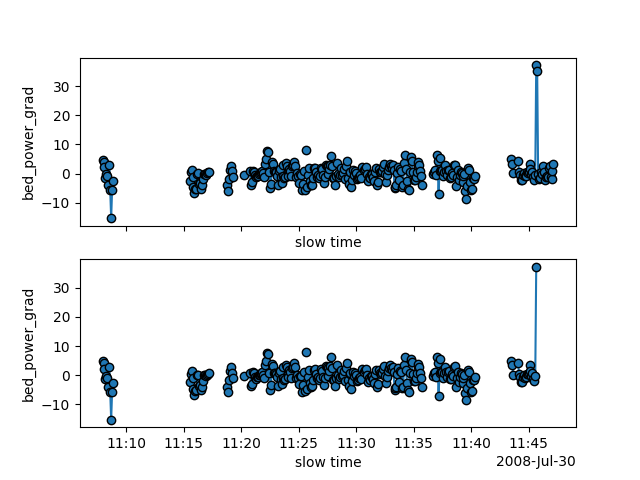

In [19]:
fig_test, (ax_test1, ax_test2) = plt.subplots(2,1, sharex=True)
reflectivity_concat['bed_power_grad'].plot(ax=ax_test1, linestyle='-',marker='o', mec='k')
bed_power_grad_filter.plot(ax=ax_test2, linestyle='-',marker='o', mec='k')
# ax_test.scatter(grad_slowtime, grad_max)

Text(0.5, 1.0, 'Bed power gradient')

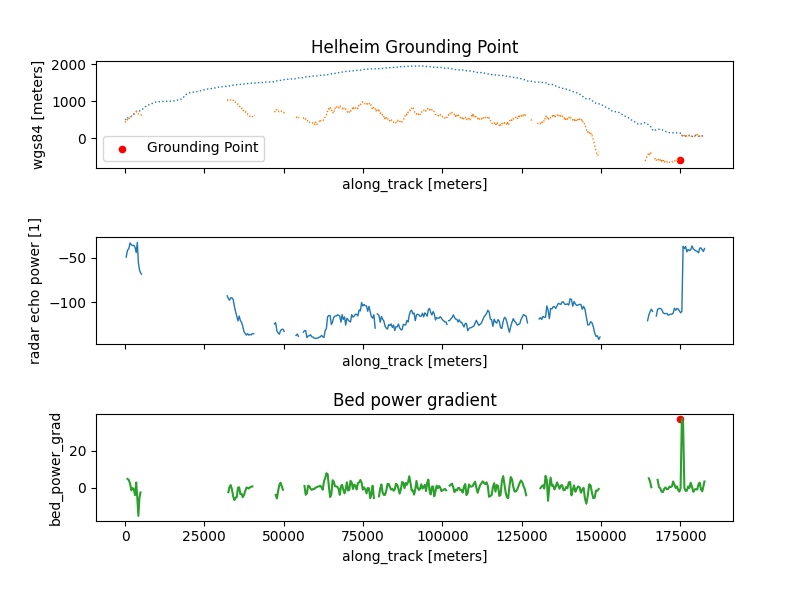

In [20]:
# Plot layers using elevation data and slow_time
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)
fig.tight_layout(pad=4.0)

for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':')#, label=layer_name)

ax1.scatter(bed_point.along_track, bed_point, color='r', s=20, label="Grounding Point")
ax1.set_title('Helheim Grounding Point')

# ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
#             alpha=0.5, label='2011-2015 gz')


reflectivity_concat['bed_power_dB'].plot(ax=ax2, x='along_track', linewidth=1)
# for result in results:
#     result = xopr.radar_util.add_along_track(result)
#     result['bed_power_dB'].plot(ax=ax2, x='along_track', label='Bed Power dB', color='tab:green')
# ax3.scatter(grad_slowtime, grad_max, color='r', s=20, label="Grounding Point")


# Plot layers using elevation data
#ax3 plot
reflectivity_concat['bed_power_grad'].plot(ax=ax3, x='along_track', label='bed_grad', color='tab:green')
ax3.scatter(bed_point.along_track, grad_max, color='r', s=20, label="Grounding Point")

ax1.legend()
# ax3.legend()
ax3.set_title('Bed power gradient')
# fig.savefig('/home/m484s199/gline_figures/petermann_20100420_merged_frame.png', dpi=300)

In [21]:
# visualize radargram

clb_min_pct, clb_max_pct  = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(flight_line.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1)#, vmin=-310, vmax=-240) #-310 -240

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)

# Plot Grounding Point
ax1.scatter(bed_point.along_track, bed_point, color='r', s=20, label="Grounding Point")


# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
# ax1.set_xlim(0.3e6, 0.5e6)
# fig.savefig('/home/m484s199/grounding_point_figs/helheim_grounding_point_20080730.png', dpi=300)